## Лабораторная работа №1: Многомерная оптимизация сложной функции генетическим алгоритмом


**ФИО студента**: Еремихина Мария Глебовна

**Вариант**: V = ~~1 + ((17N + 7Q + Y) mod 20)~~ = 20

Начнем выполнение данной лабораторной работы с написания **вычисления функции**, минимум которой мы пытаемся посчитать. В нашем случае это функция **HGBat**:

$HGBat(x)= \sqrt{\left|\left(\sum_{i=1}^{d}x_i^2\right)^2- \left(\sum_{i=1}^{d}x_i\right)^2\right|} + \frac{\frac{1}{2}\sum_{i=1}^{d}x_i^2+\sum_{i=1}^{d}x_i}{d} +\frac{1}{2}$

$d=7,\qquad x_i\in[-15,15]$

In [119]:
def hgbat(x):
    s = sum(x)
    s2 = sum([i ** 2 for i in x])
    return abs(s2 ** 2 - s ** 2) ** 0.5 + (0.5 * s2 + s) / len(x) + 0.5

Для реализации нам необходимо зафиксировтаь некоторые **константы**:
1. `D = 7` - размерность одной особи популяции $x = (x_1, x_2, x_3, x_4, x_5, x_6, x_7)$
2. `LOW_BOUND = -15` - нижняя граница для элементов особи
3. `HIGH_BOUND = 15` - верхняя граница для элементов особи
4. `POPULATION_SIZE = 50` - количество особей в начальной популяции

In [120]:
D = 7
LOW_BOUND = -15
HIGH_BOUND = 15
POPULATION_SIZE = 50

Следующим шагом нам необходимо **уметь создавать популяцию** определенной длины и размерности

In [121]:
import numpy as np
def get_population():
    return np.random.uniform(LOW_BOUND, HIGH_BOUND, size=(POPULATION_SIZE, D))

population = get_population()
population.shape

(50, 7)

In [122]:
population[0]

array([-4.8241277 ,  0.73971012,  7.6683403 , -7.67535702,  7.17814399,
       14.10988307, -1.08184954])

Теперь нам надо применить функцию **HGBat** ко всем особям популяции с последующим выбором **лучшей**

In [123]:
def find_best(population):
    fitness = [hgbat(i) for i in population]
    best_index = np.argmin(fitness)
    best_fitness = fitness[best_index]
    return best_index, best_fitness

index, fitness = find_best(population)
index, fitness

(np.int64(45), np.float64(206.49253731898244))

Нам необходимо написать функцию, которая будет проводить **турниры** и выбирать будущих родителей для следующего поколения. Задача: на каждом шаге из рандомного набора из **n** особей выбирать особь с минимальным значением, таким образом проводя естественный отбор

In [124]:
def choose_parents(population, n=3):
    parents = []
    fitness = np.array([hgbat(i) for i in population])
    for i in range(POPULATION_SIZE):
        tmp = np.random.choice(POPULATION_SIZE, n, replace=False)
        winner = tmp[np.argmin(fitness[tmp])]
        parents.append(population[winner])
    return np.array(parents)

parents = choose_parents(population)
parents.shape

(50, 7)

Самое время для _кроссинговера_ - вывода детей из текущего состава родителей. Начнем с **алгебраического кроссинговера**, который максимально удобен для вещественных чисел:

$child=\alpha parent_1+(1-\alpha)parent_2$, где $\alpha\in[0,1]$.

Нам также надо ввести некоторые новые **параметры**:
1. $\alpha$ - параметр, отвечающий за личный вклад каждого из родителей
2. `CROSS_PROB = 0.8` - вероятность применения кроссинговера, а не простого копирования одного из родителей

In [125]:
CROSS_PROB = 0.8

def crossover(parents):
    children = []
    for i in range(0, len(parents) - 1, 2):
        parent1 = parents[i]
        parent2 = parents[i + 1]
        if np.random.rand() < CROSS_PROB:
            alpha = np.random.rand()
            child1 = alpha * parent1 + (1 - alpha) * parent2
            child2 = alpha * parent2 + (1 - alpha) * parent1
        else:
            child1 = parent1.copy()
            child2 = parent2.copy()
        for j in range(D):
            child1[j] = np.clip(child1[j], -15, 15)
            child2[j] = np.clip(child2[j], -15, 15)
        children.append(child1)
        children.append(child2)
    return np.array(children)

children = crossover(parents)
children.shape

(50, 7)

Теперь мы должны как-то изменить текущие особи, ведь в процессе скрещивания родителей некоторые вещественные параметры меняются (появляются **мутации**). В качестве изменения возьмем некий $\varepsilon$, который будет распределен по **нормальному** закону:

$x_i' = x_i + \varepsilon,\qquad$
$\varepsilon\sim N(0,\sigma^2)$

Нам снова необходимы некоторые параметры, для задавания **рандома**:
1. `SIGMA = 0.5` - дисперсия нашего нормального распределения, в пределах которого мы выбираем $\varepsilon$
2. `MUT_PROB = 0.1` - вероятность того, что мутация необходима для текущей особи

In [126]:
SIGMA = 0.5
MUT_PROB = 0.1

def mutate(children):
    for child in children:
        for i in range(len(child)):
            if np.random.rand() < MUT_PROB:
                child[i] += np.random.normal(0, SIGMA)
                child[i] = np.clip(child[i], -15, 15)
    return children

mut_children = mutate(children)
mut_children.shape

(50, 7)

Вот мы расписали все основные функции для одного поколения, можем теперь перейти к **основной функции**, которая будет содержать полный комплекс всех перечисленных сверху функций, но не будем забывать, что нам нужен **элитизм**, то есть мы всегда должны хранить наименьший результат на n-ом поколении и передавать особь дальше, именно поэтому на каждой итерации мы будем наибольший результат заменять на наилучший

In [127]:
def next_generation(population, n=3):
    index, fitness = find_best(population)
    elite = population[index].copy()
    parents = choose_parents(population, n)
    children = crossover(parents)
    mut_children = mutate(children)
    mut_children[np.argmax([hgbat(x) for x in children])] = elite
    return np.array(mut_children)

Мы все подготовили, теперь давайте запускать **n-ое количество итераций** и на каждом шагу смотреть, какое наименьшее значение HGBat мы получаем:

`NUMBER_GEN = 100` - количество итераций генетического алгоритма

In [130]:
NUMBER_GEN = 100
best_history = []
for i in range(NUMBER_GEN):
    population = next_generation(population)
    index, fitness = find_best(population)
    best_history.append(fitness)

А чтобы посмотреть сходимость от количества эпох или поколений, построим простой **график** зависимости

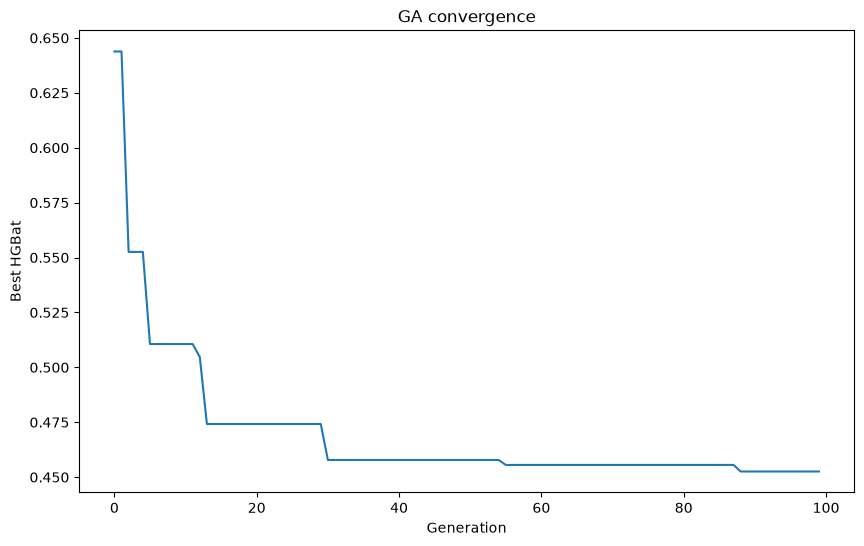

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(best_history)
plt.xlabel("Generation")
plt.ylabel("Best HGBat")
plt.title("GA convergence")
plt.show()

Так как сейчас мы будем запускать незаисимо 20 испытаний, **сохраним** текущий минимум и лучшую особь, чтобы потом посмотреть и сравнить

In [132]:
print("Best individual:", population[index])
print("Best HGBat:", fitness)

Best individual: [ 0.16627638 -0.28862854  0.23484892 -0.70267765  0.15470597 -0.03346264
 -0.68587817]
Best HGBat: 0.4525744441406233


Теперь, добавив генерацию популяции на каждой запуске, мы можем посмотреть картину **20** запусков. Не забудем добавить оба варианта остановки генетического алгоритма:
1. количество эпох/**поколений** достигло максимума
2. количество вызова функции **HGBAt** достигло максимума

In [133]:
MAX_EVALS = 10000
def run_ga():
    population = get_population()
    best_history = []
    evaluations = 0
    generation = 0
    while generation < NUMBER_GEN and evaluations < MAX_EVALS:
        population = next_generation(population)
        index, fitness = find_best(population)
        best_history.append(fitness)
        generation += 1
        evaluations += POPULATION_SIZE * 2
    return best_history

In [134]:
RUNS = 20
all_histories = np.array([run_ga() for i in range(RUNS)])
all_histories.shape

(20, 100)

Давайте также выведем все наши **20** испытаний на **одну плоскость**, чтобы посмотреть различные реализации генетического алгоритма

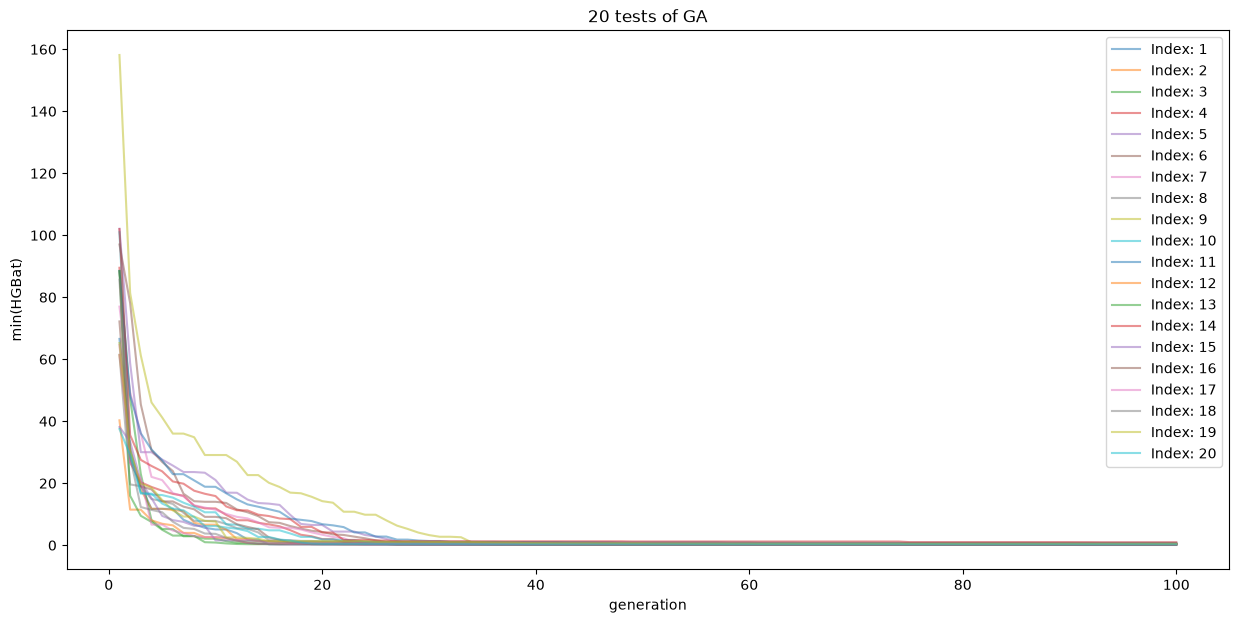

In [135]:
plt.figure(figsize=(15, 7))
for i in range(RUNS):
    plt.plot([i for i in range(1, NUMBER_GEN + 1)], all_histories[i], alpha=0.5, label=f"Index: {i + 1}")

plt.xlabel("generation")
plt.ylabel("min(HGBat)")
plt.title("20 tests of GA")
plt.legend(fontsize=10)
plt.show()

Посмотрим еще за изменением **статистических параметров** с изменения запуска: максимум, минимум и среднее значение - медиана и **построим графики**, чтобы визуально просмотреть все детали

In [143]:
min_history = np.min(all_histories, axis=0)
mean_history = np.mean(all_histories, axis=0)
max_history = np.max(all_histories, axis=0)

print("mean:", mean_history[-1])
print("min:", min_history[-1])
print("max:", max_history[-1])

mean: 0.3941372071067164
min: 0.07303207091389141
max: 0.955179729710644


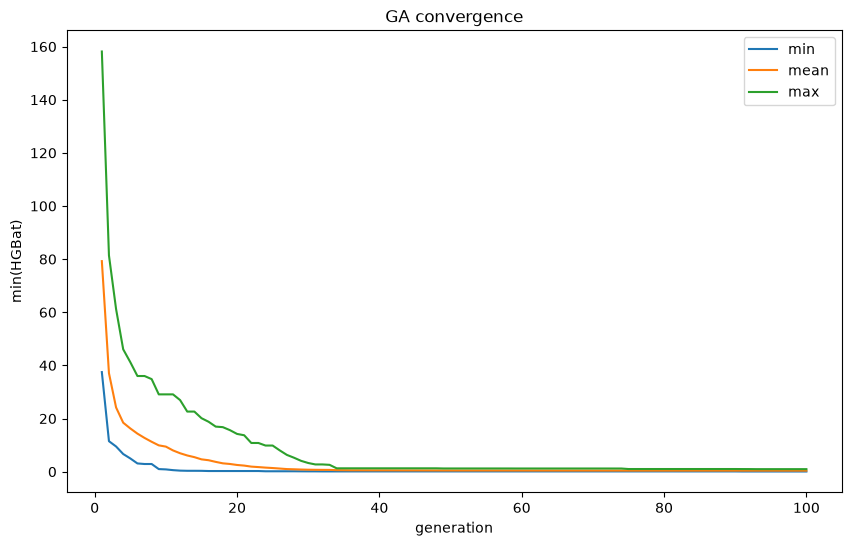

In [137]:
plt.figure(figsize=(10, 6))
plt.plot([i for i in range(1, NUMBER_GEN + 1)], min_history, label="min")
plt.plot([i for i in range(1, NUMBER_GEN + 1)], mean_history, label="mean")
plt.plot([i for i in range(1, NUMBER_GEN + 1)], max_history, label="max")

plt.xlabel("generation")
plt.ylabel("min(HGBat)")
plt.title("GA convergence")
plt.legend()
plt.show()

Давайте попробуем изменить некоторые параметры и алгоритма и посмотрим, что изменится. Начнем с изменения вероятности мутации: `MUT_PROB = 0.2` и посмотрим что у нас получилось изменить

In [144]:
MUT_PROB = 0.2

all_histories_01 = np.array([run_ga() for _ in range(RUNS)])
all_histories_01.shape

(20, 100)

In [145]:
print("MUT_PROB = 0.2")
print("mean:", np.mean(all_histories_01[:, -1]))
print("min:", np.min(all_histories_01[:, -1]))
print("max:", np.max(all_histories_01[:, -1]))

MUT_PROB = 0.1
mean: 0.3835036106699585
min: 0.06556582746280415
max: 0.4677571645399492


А теперь изменим этот же параметр, но сделаем его **намного больше**, чтобы посмотреть насколько изменятся статистические параметры алгоритма: `MUT_PROB = 0.8`

In [146]:
MUT_PROB = 0.8

all_histories_02 = np.array([run_ga() for _ in range(RUNS)])
all_histories_02.shape

(20, 100)

In [147]:
print("MUT_PROB = 0.8")
print("mean:", np.mean(all_histories_02[:, -1]))
print("min:", np.min(all_histories_02[:, -1]))
print("max:", np.max(all_histories_02[:, -1]))

MUT_PROB = 0.8
mean: 0.24958793742140545
min: 0.12225582089611803
max: 0.3250387446579492


Для понимания того, насколько влияет вообще MUT_PROB, построим **графики** изменения среднего значения по HGBat

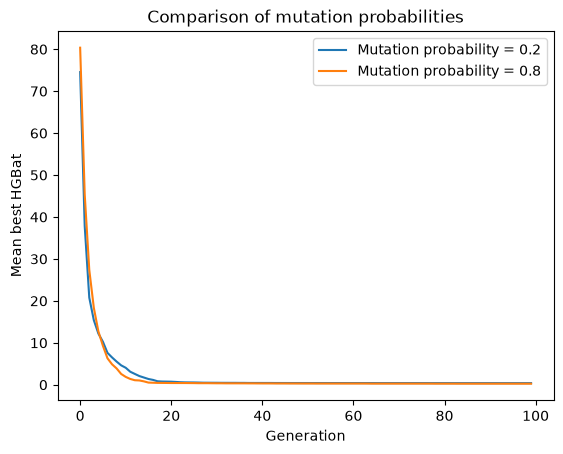

In [148]:
mean_01 = np.mean(all_histories_01, axis=0)
mean_02 = np.mean(all_histories_02, axis=0)

plt.plot(mean_01, label="Mutation probability = 0.2")
plt.plot(mean_02, label="Mutation probability = 0.8")

plt.xlabel("Generation")
plt.ylabel("Mean best HGBat")
plt.title("Comparison of mutation probabilities")
plt.legend()
plt.show()

Встает **вопрос**: а может нам не надо так париться насчет каких-то алгоритмов и просто использовать рандомные значения

In [157]:
def random_search():
    best_fitness = float("inf")
    history = []
    evaluations = 0
    generation = 0
    while generation < NUMBER_GEN and evaluations < MAX_EVALS:
        x = np.random.uniform(-15, 15, D)
        fitness = hgbat(x)
        best_fitness = min(best_fitness, fitness)
        history.append(best_fitness)
        generation += 1
        evaluations += POPULATION_SIZE * 2
    return history

random_results = np.array([random_search() for i in range(RUNS)])

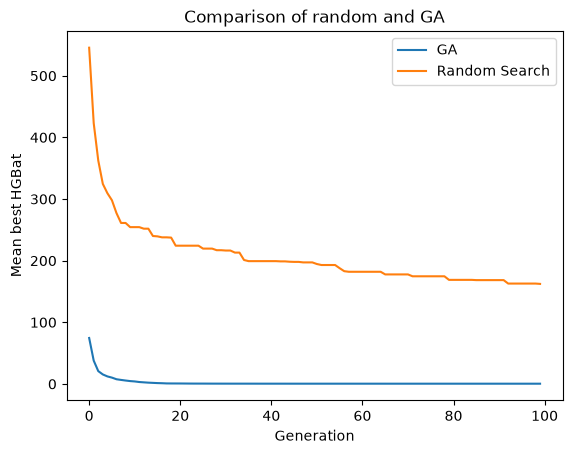

In [158]:
ga_mean = np.mean(all_histories_01, axis=0)
random_mean = np.mean(random_results, axis=0)
plt.plot(ga_mean, label="GA")
plt.plot(random_mean, label="Random Search")
plt.xlabel("Generation")
plt.ylabel("Mean best HGBat")
plt.title("Comparison of random and GA")
plt.legend()
plt.show()

Подведем некий **итог** лабораторной работы и ответим на вопрос: _Объясните, почему выбранная функция создаёт сложность для простого локального поиска или случайного поиска_

**Ответ**: Функция HGBat является сложной для простого локального и случайного поиска из-за многомерности и нелинейной зависимости координат (значение функции зависит не от отдельных координат, а от суммы и суммы квадратов). Кроме того, наличие квадратного корня и абсолютного значения создаёт сложный рельеф целевой функции. Случайному поиску требуется большое количество вычислений, чтобы случайно попасть в область минимума, а локальный поиск может быть чувствителен к начальному положению и плохо исследовать всю область поиска

Теперь выполним **дополнительное задание**, а именно **адаптивный масштаб гауссовской мутации**. В чем заключается задание? Мы берем изначально большую SIGMA, например, 0.5, а потом постепенно уменьшаем, чтобы сокращать разброс дисперсии. Возьмем в качестве рекурентной формулы для SIGMA следующую:

$\sigma = 1.0 * 0.99^{generation}$

Перепишем все текущие функции, добавив параметр **SIGMA**

In [162]:
def mutate(children, sigma):
    for child in children:
        for i in range(len(child)):
            if np.random.rand() < MUT_PROB:
                child[i] += np.random.normal(0, sigma)
                child[i] = np.clip(child[i], -15, 15)
    return children

def next_generation(population, generation, n=3):
    index, fitness = find_best(population)
    elite = population[index].copy()
    parents = choose_parents(population, n)
    children = crossover(parents)
    sigma = 1.0 * (0.99 ** generation)
    children = mutate(children, sigma)
    worst_index = np.argmax([hgbat(x) for x in children])
    children[worst_index] = elite
    return np.array(children)

def run_ga():
    population = get_population()
    best_history = []
    evaluations = 0
    generation = 0
    while generation < NUMBER_GEN and evaluations < MAX_EVALS:
        population = next_generation(population, generation)
        index, fitness = find_best(population)
        best_history.append(fitness)
        generation += 1
        evaluations += POPULATION_SIZE * 2
    return best_history

Ну а теперь стандартно запустим весь процесс и выведем график для всех **20** запусков

In [163]:
all_histories_adaptive = np.array([run_ga() for _ in range(RUNS)])

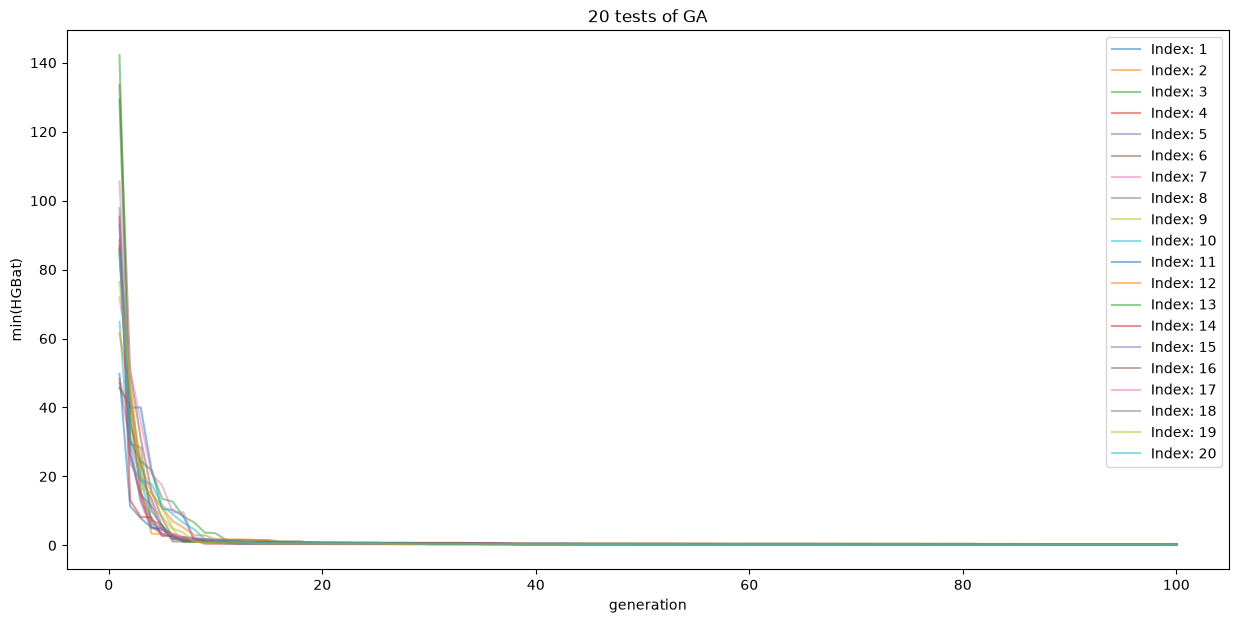

In [164]:
plt.figure(figsize=(15, 7))
for i in range(RUNS):
    plt.plot([i for i in range(1, NUMBER_GEN + 1)], all_histories_adaptive[i], alpha=0.5, label=f"Index: {i + 1}")

plt.xlabel("generation")
plt.ylabel("min(HGBat)")
plt.title("20 tests of GA")
plt.legend(fontsize=10)
plt.show()

Можем заметить, что при использовании неконстантной сигмы график минимума HGBat **спадает намного быстрее**, что доказывает _эффективность_ адаптивного шага